In [1]:
!pip install hd-bet --quiet

In [2]:
!pip install ants --quiet

In [3]:
!pip install antspyx --quiet

In [5]:
INPUT_IMAGE  = "image/464357.nii.gz"
TARGET_SHAPE = (96, 96, 96)

In [6]:
import numpy as np, nibabel as nib, ants, matplotlib.pyplot as plt
import subprocess, tempfile
from pathlib import Path

try:
    MNI = ants.image_read(ants.get_ants_data("mni"))
except:
    MNI = ants.image_read(ants.get_data("mni"))

def plot(vol, title):
    arr = vol.numpy() if hasattr(vol, "numpy") else vol
    z   = arr.shape[2] // 2
    plt.figure(figsize=(5, 5))
    plt.imshow(arr[:, :, z].T, cmap="gray", origin="lower")
    plt.title(f"{title}\nshape={arr.shape}  range=[{arr.min():.1f}, {arr.max():.1f}]")
    plt.axis("off"); plt.show()

print(f"MNI template: {MNI.shape}  spacing: {MNI.spacing}")

MNI template: (182, 218, 182)  spacing: (1.0, 1.0, 1.0)


Input shape: (176, 240, 256)  spacing: (1.1999999284744263, 1.0, 1.0)


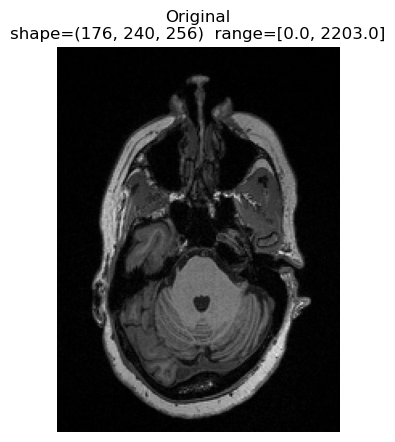

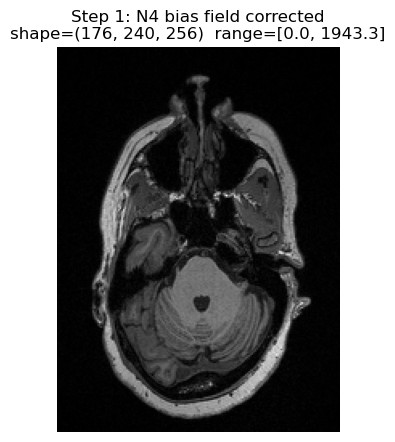

In [7]:
img = ants.image_read(INPUT_IMAGE)
print(f"Input shape: {img.shape}  spacing: {img.spacing}")
plot(img, "Original")

img_n4 = ants.n4_bias_field_correction(img, shrink_factor=8,
                                        convergence={"iters": [30, 20], "tol": 1e-4})
plot(img_n4, "Step 1: N4 bias field corrected")


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting brain_bet.nii.gz:
perform_everything_on_device: True


100%|██████████| 20/20 [00:17<00:00,  1.14it/s]


sending off prediction to background worker for resampling and export
done with brain_bet.nii.gz
GPU prediction completed. Waiting for remaining segmentation exports to finish...


Segmentation export complete.


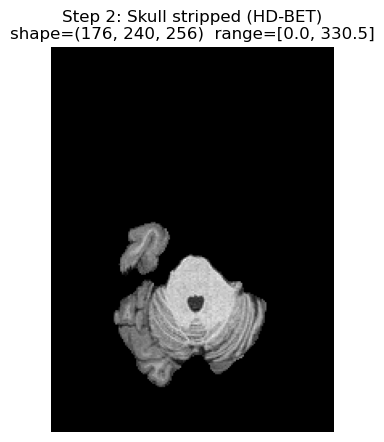

Brain voxels: 922262


In [11]:
import os
os.environ["MPLBACKEND"] = "agg"

with tempfile.TemporaryDirectory() as tmp:
    in_path  = Path(tmp) / "in.nii.gz"
    out_path = Path(tmp) / "brain.nii.gz"
    ants.image_write(img_n4, str(in_path))
    subprocess.run(["hd-bet", "-i", str(in_path), "-o", str(out_path),
                    "-device", "cuda", "--save_bet_mask"],
                   check=True, env={**os.environ, "MPLBACKEND": "agg"})
    mask_path = Path(tmp) / "brain_bet.nii.gz"
    if not mask_path.exists():
        mask_path = Path(tmp) / "brain_mask.nii.gz"
    brain_arr = ants.image_read(str(out_path)).numpy()
    mask_arr  = ants.image_read(str(mask_path)).numpy()

img_brain  = ants.from_numpy(brain_arr, origin=img_n4.origin,
                              spacing=img_n4.spacing, direction=img_n4.direction)
brain_mask = ants.from_numpy(mask_arr,  origin=img_n4.origin,
                              spacing=img_n4.spacing, direction=img_n4.direction)

plot(img_brain, "Step 2: Skull stripped (HD-BET)")
print(f"Brain voxels: {int((mask_arr > 0.5).sum())}")

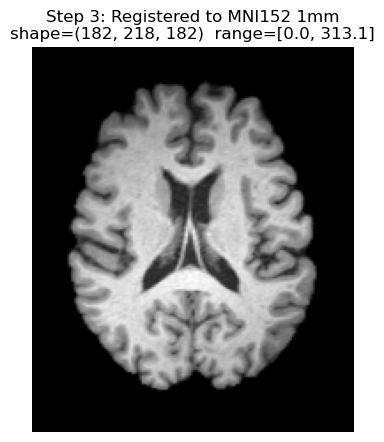

In [12]:
reg       = ants.registration(fixed=MNI, moving=img_brain, type_of_transform="Affine")
img_mni   = reg["warpedmovout"]
mask_mni  = ants.apply_transforms(fixed=MNI, moving=brain_mask,
                                   transformlist=reg["fwdtransforms"],
                                   interpolator="nearestNeighbor")
plot(img_mni, "Step 3: Registered to MNI152 1mm")

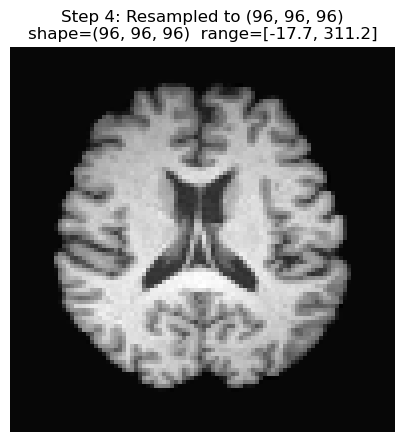

In [13]:
img_small  = ants.resample_image(img_mni,  TARGET_SHAPE, use_voxels=True, interp_type=4)
mask_small = ants.resample_image(mask_mni, TARGET_SHAPE, use_voxels=True, interp_type=1)

plot(img_small, f"Step 4: Resampled to {TARGET_SHAPE}")

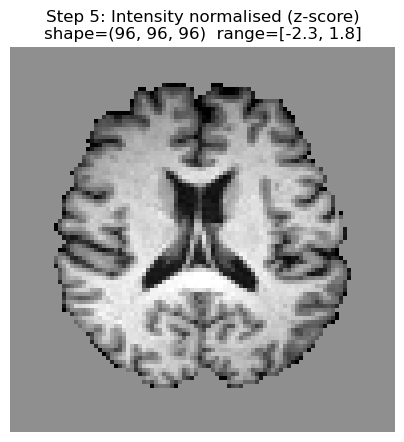

Brain mean=0.000  std=1.000


In [14]:
arr  = img_small.numpy()
m    = mask_small.numpy() > 0.5
lo, hi = np.percentile(arr[m], [1, 99])
arr  = np.clip(arr, lo, hi)
mean, std = arr[m].mean(), arr[m].std()
arr  = ((arr - mean) / (std + 1e-8)) * m
img_norm = arr.astype(np.float32)

plot(img_norm, "Step 5: Intensity normalised (z-score)")
print(f"Brain mean={img_norm[m].mean():.3f}  std={img_norm[m].std():.3f}")